In [1]:
import random
import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq
import anndata as ad

import timeit
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import adjusted_rand_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

In [2]:
from CellPos.preprocessing import preprocess
from CellPos.train import SpaceReconstructor, evaluate

## Data loading

In [3]:
sc_obj = sc.read_visium('/.../data/Human_DLPFC/151673/',
                         count_file='151673_filtered_feature_bc_matrix.h5', library_id="151673", load_images=True,
                         source_image_path="/.../data/Human_DLPFC/151673/spatial/")
labels_sc = pd.read_csv('/.../data/Human_DLPFC/cluster/cluster_labels_151673.csv')
labels_sc['key'] = labels_sc['key'].str.replace('151673_', '', regex=False)
labels_sc.set_index('key', inplace=True)
sc_obj.obs['cluster'] = sc_obj.obs.index.map(labels_sc['ground_truth'])
sc_obj = sc_obj[~sc_obj.obs['cluster'].isna()].copy()
# encoder = LabelEncoder()
# sc_obj.obs['label'] = encoder.fit_transform(sc_obj.obs['cluster'])
print("sc:", sc_obj)

sc: AnnData object with n_obs × n_vars = 3611 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


In [4]:
st_obj = sc.read_visium('/.../data/Human_DLPFC/151674/',
                         count_file='151674_filtered_feature_bc_matrix.h5', library_id="151674", load_images=True,
                         source_image_path="/.../data/Human_DLPFC/151674/spatial/")
labels_st = pd.read_csv('/.../data/Human_DLPFC/cluster/cluster_labels_151674.csv')
labels_st['key'] = labels_st['key'].str.replace('151674_', '', regex=False)
labels_st.set_index('key', inplace=True)
st_obj.obs['cluster'] = st_obj.obs.index.map(labels_st['ground_truth'])
st_obj = st_obj[~st_obj.obs['cluster'].isna()].copy()
label_encoder = LabelEncoder()
st_obj.obs['label'] = label_encoder.fit_transform(st_obj.obs['cluster'])
print("st:", st_obj)

st: AnnData object with n_obs × n_vars = 3635 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', 'label'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


## Date Processing

In [5]:
sc_adata, st_adata = preprocess(sc_adata=sc_obj, st_adata=st_obj,
                                hvg_features=3000, svg_features=3000, 
                                select_gene='union') #select_hvg='union'or'intersection'

sc_adata: AnnData object with n_obs × n_vars = 3608 × 2527
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'log1p', 'hvg'
    obsm: 'spatial', 'spatial_centered', 'spatial_normalized'
st_adata: AnnData object with n_obs × n_vars = 3635 × 2527
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', 'label', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'log1p', 'hvg', 'spatial_neighbors', 'moranI'
    obsm: 'spatial', 'spatial_centered', 'spatial_normalized'
    obsp: 'spatial_connectivities', 'spatial_distances'
Data have been pre-processed!


## Training

In [6]:
reconstructor = SpaceReconstructor(device='cuda:1', seed=2026)
p_config = {'encoder': {'hidden_dims': 'dropout': [0.1, 0, 0]},
             'decoder': {'hidden_dims': 'dropout': [0.1, 0, 0]},
             'pred': {'hidden_dims': [128, 64, 64], 'dropout': [0.1, 0, 0]}}
sc_adata, st_adata, m_sc, m_st, m_p = reconstructor.fit(sc_adata, st_adata, 
                                                        lr = 0.001, 
                                                        pretrain_epoch_num=1500, 
                                                        fulltrain_epoch_num=1500,
                                                        custom_config=p_config,)

--- Phase 1: Pre-training ---


embedding_pretrain:  33%|███████████████████████                                              | 501/1500 [01:00<02:00,  8.29it/s, loss=0.1250]

Epoch [500/1500], Loss: 0.1252


embedding_pretrain:  67%|█████████████████████████████████████████████▍                      | 1001/1500 [02:01<01:00,  8.24it/s, loss=0.1204]

Epoch [1000/1500], Loss: 0.1204


...

Epoch [500/1500], Loss: 0.1304


full_training:  67%|████████████████████████████████████████████████▋                        | 1001/1500 [02:15<01:05,  7.65it/s, loss=0.1297]

Epoch [1000/1500], Loss: 0.1297


full_training: 100%|█████████████████████████████████████████████████████████████████████████| 1500/1500 [03:23<00:00,  7.38it/s, loss=0.1294]


Epoch [1500/1500], Loss: 0.1294
Total time: 387.03s


## Evaluating

In [7]:
sc_adata.obs['cluster_pred'] = label_encoder.inverse_transform(sc_adata.obs['label_pred'])
evaluate(sc_adata,compute_jsd_flag=False)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 3608/3608 [00:06<00:00, 537.34it/s]


For PCC: 0.8587,  PCC of pair distance: 0.7440
MSE: 1370396.0806,  MAE: 793.1598(±1074.6015 SD)
Hit_rate (10-20-50-100): 0, 1, 6, 21
Adjusted Rand Index (ARI_sc): 0.5584


## Visualization 

### Visualization (1)

In [8]:
colors = ["#E11E25","#FAA09C","#F38B2F","#FFBC80","#0C4E9B","#92BEDB","#03C088",] # DLPFC

In [9]:
sc_adata.obsm['spatial'][:, 1] = -1*sc_adata.obsm['spatial'][:, 1]
sc_adata.obsm['spatial_pred'][:, 1] = -1*sc_adata.obsm['spatial_pred'][:, 1]

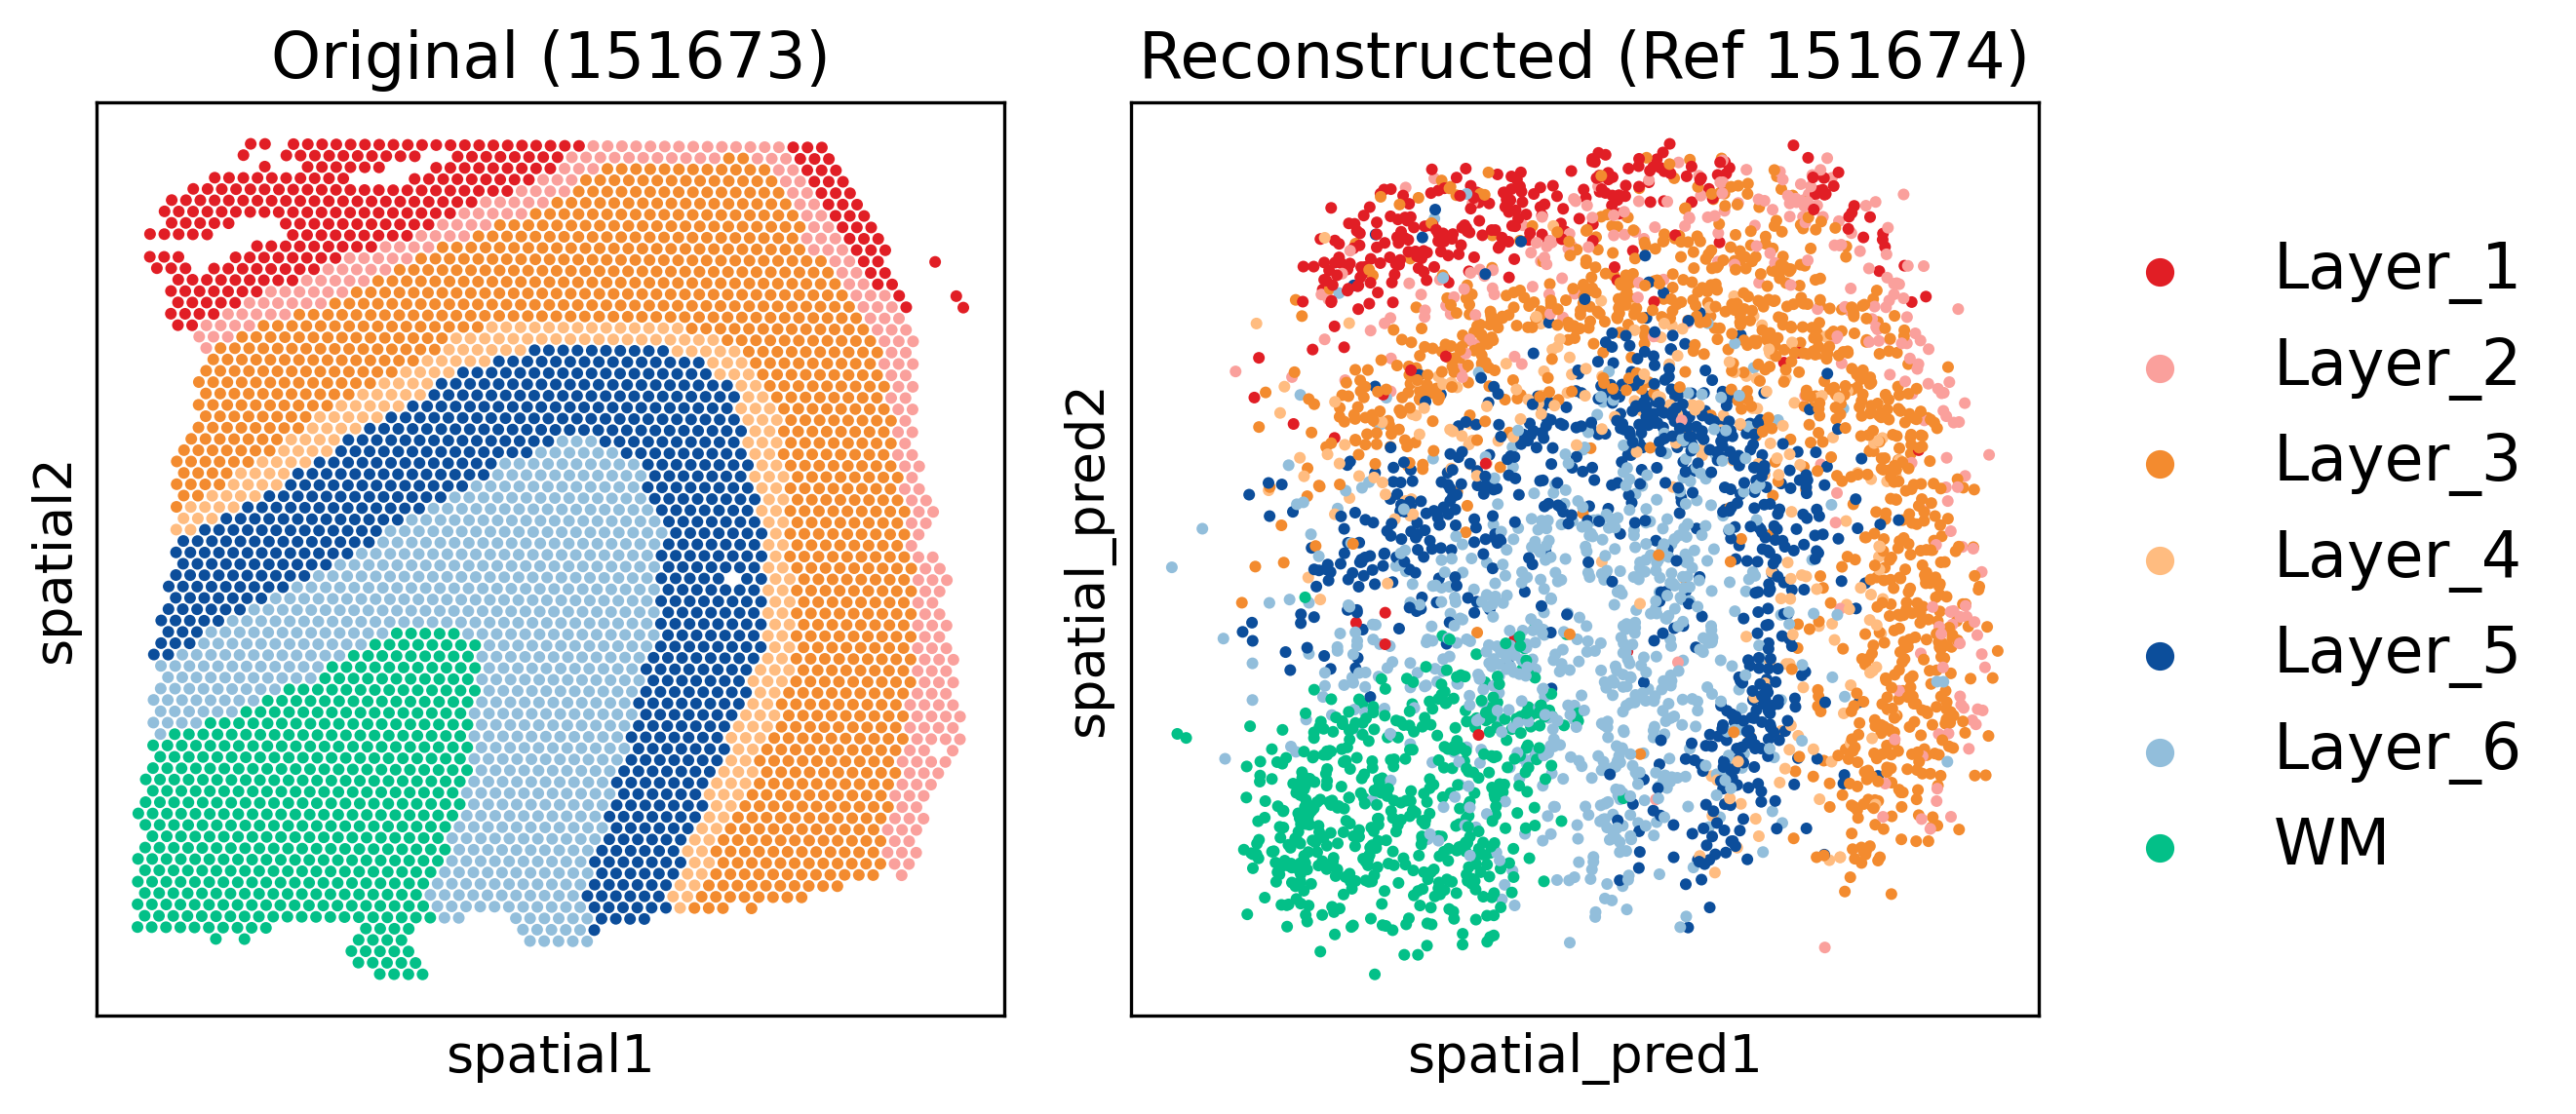

In [10]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 13
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
plt.sca(axes[0])
sc.pl.embedding(sc_adata, basis='spatial', color='cluster', palette = colors, title='Original (151673)',
                show=False, legend_loc=None, ax=axes[0]) # basis='spatial_normalized'
plt.sca(axes[1])
sc.pl.embedding(sc_adata, basis='spatial_pred', color='cluster', palette = colors, title='Reconstructed (Ref 151674)',
                legend_fontsize='large', show=False, ax=axes[1])
plt.tight_layout()
plt.show()

### Visualization (2)

Calculating all cell pairs between WM and Layer_1 ...
Calculating all cell pairs between WM and Layer_2 ...
Calculating all cell pairs between WM and Layer_3 ...
Calculating all cell pairs between WM and Layer_4 ...
Calculating all cell pairs between WM and Layer_5 ...
Calculating all cell pairs between WM and Layer_6 ...
Calculating all cell pairs between WM and WM ...


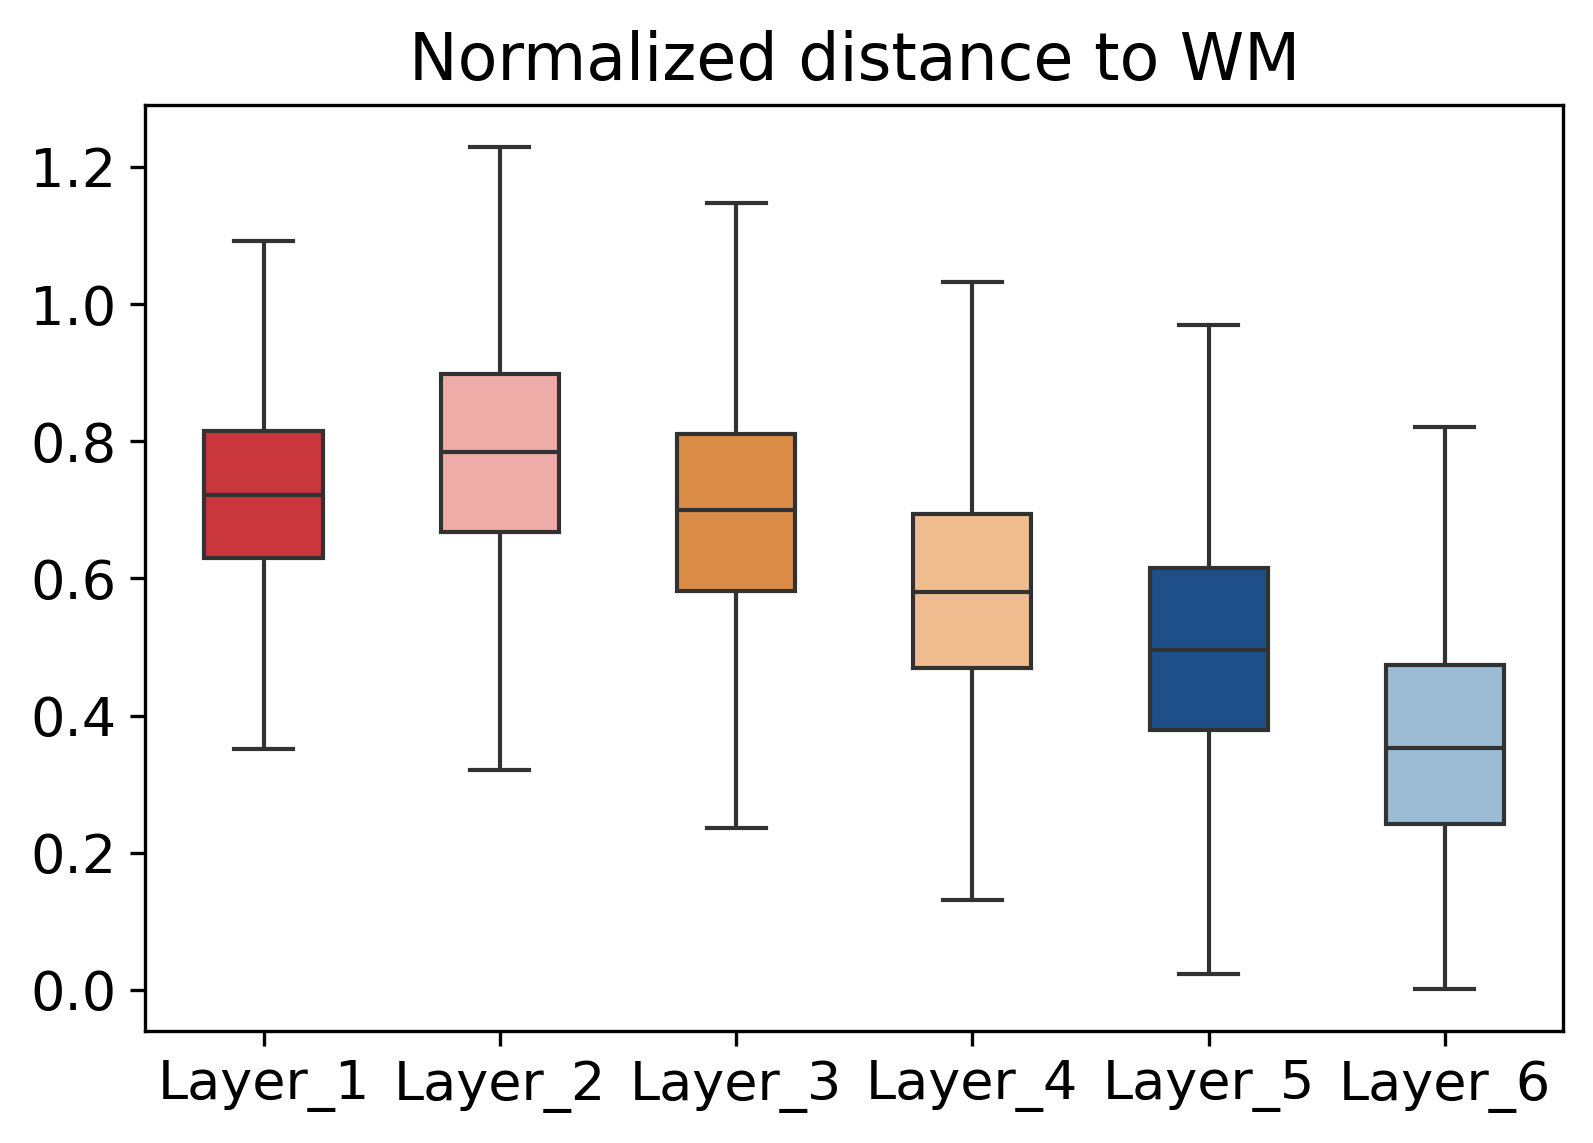

In [12]:
from CellPos.utils import *
cluster_dist_sc = cal_dist_group(sc_adata = sc_adata, group_key = 'cluster', select_group = 'WM')
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 13
fig, ax = plt.subplots(figsize=(5.5, 4)) # figsize=(6, 4.5)
bplot = sns.boxplot(cluster_dist_sc[:6], showfliers=False, vert=True, palette = colors,
                    width=0.5, ax=ax)
ax.set_xticklabels(['Layer_{}'.format(i + 1) for i in range(6)])
ax.set_title('Normalized distance to WM')
plt.tight_layout()
plt.show()

## Data saving

In [13]:
import os
output_dir = "/.../cellPos_analysis/Human_DLPFC/151674/"
os.makedirs(output_dir, exist_ok=True)
sc_adata.write(f"{output_dir}/sc_151673_refer_151674.h5ad")
st_adata.write(f"{output_dir}/st_151674.h5ad")

In [14]:
sc_embed_model_save_path = os.path.join(output_dir, 'sc_151673_refer_151674_embed_model.pth')
st_embed_model_save_path = os.path.join(output_dir, 'st_151674_embed_model.pth')
pred_model_save_path = os.path.join(output_dir, 'sc_151673_refer_151674_pred_model.pth')
torch.save(m_sc, sc_embed_model_save_path) 
torch.save(m_st, st_embed_model_save_path) 
torch.save(m_p, pred_model_save_path) 